In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Most of these come pre-installed in Colab; this is just a safety net
!pip install -q torch pandas numpy

Mounted at /content/drive


In [3]:
from __future__ import annotations
import json
import random
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import torch

In [4]:
DATA_DIR = Path("/content/drive/MyDrive/ForeSight/data/")
OUTPUT_DIR = Path("/content/drive/MyDrive/ForeSight/outputs/")

REQUIRED_COLUMNS = ["userID", "sessionID", "packageName", "timestamp", "eventType"]
SEQUENCE_LENGTH = 10
TARGET_EVENT_TYPE = "OPENED"
TIME_SINCE_LAST_CAP_SECONDS = 3600
RANDOM_SEED = 42

In [5]:
COLUMN_ALIASES = {
    "userID": {"userid", "user_id", "user", "uid"},
    "sessionID": {"sessionid", "session_id", "session", "sid"},
    "packageName": {
        "packagename", "package_name", "package",
        "app_name", "appname", "targetapp", "app",
    },
    "timestamp": {"time", "datetime", "date_time", "event_time", "eventtime", "ts"},
    "eventType": {"eventtype", "event_type", "event", "type"},
}

## File discovery & loading utilities

In [6]:
def discover_data_files(data_dir: Path) -> List[Path]:
    patterns = ["*.csv", "*.tsv", "*.txt", "*.parquet", "*.json", "*.jsonl"]
    files: List[Path] = []
    for pattern in patterns:
        files.extend(data_dir.glob(pattern))

    files = [
        file for file in files
        if file.is_file() and OUTPUT_DIR not in file.parents and not file.name.startswith(".")
    ]
    if not files:
        raise FileNotFoundError(
            f"No data files found in {data_dir}. Expected CSV/TSV/TXT/Parquet/JSON files."
        )
    return sorted(files)


def read_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix in {".json", ".jsonl"}:
        return pd.read_json(path, lines=suffix == ".jsonl")
    if suffix == ".tsv":
        return pd.read_csv(path, sep="\t")
    if suffix == ".txt":
        try:
            return pd.read_csv(path, sep=None, engine="python")
        except Exception:
            return pd.read_csv(path, sep="\t")
    return pd.read_csv(path)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    normalized_lookup = {
        "".join(ch for ch in str(col).strip().lower() if ch.isalnum()): col
        for col in df.columns
    }

    rename_map = {}
    for canonical, aliases in COLUMN_ALIASES.items():
        candidates = {canonical.lower(), *aliases}
        candidates = {"".join(ch for ch in c.lower() if ch.isalnum()) for c in candidates}
        for candidate in candidates:
            if candidate in normalized_lookup:
                rename_map[normalized_lookup[candidate]] = canonical
                break

    df = df.rename(columns=rename_map)
    missing = [column for column in REQUIRED_COLUMNS if column not in df.columns]
    if missing:
        raise ValueError(
            f"Missing required columns {missing}. Available columns: {list(df.columns)}"
        )
    return df[REQUIRED_COLUMNS].copy()


def load_lsapp(data_dir: Path) -> pd.DataFrame:
    files = discover_data_files(data_dir)
    print(f"Found {len(files)} input file(s):")
    for file in files:
        print(f"  - {file.name}")

    frames = []
    for file in files:
        df = read_table(file)
        frames.append(normalize_columns(df))

    df = pd.concat(frames, ignore_index=True)
    print(f"Loaded raw rows: {len(df):,}")
    return df

## Event preprocessing

In [7]:
def parse_timestamp(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    numeric_ratio = numeric.notna().mean()

    if numeric_ratio >= 0.9:
        median_value = numeric.dropna().median()
        if median_value > 1e17:
            unit = "ns"
        elif median_value > 1e14:
            unit = "us"
        elif median_value > 1e11:
            unit = "ms"
        else:
            unit = "s"
        return pd.to_datetime(numeric, unit=unit, errors="coerce", utc=True)

    return pd.to_datetime(series, errors="coerce", utc=True)


def preprocess_events(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna(subset=["userID", "packageName", "timestamp", "eventType"]).copy()
    df["eventType"] = df["eventType"].astype(str).str.strip().str.upper()
    df = df[df["eventType"] == TARGET_EVENT_TYPE].copy()

    df["timestamp"] = parse_timestamp(df["timestamp"])
    df = df.dropna(subset=["timestamp"]).copy()

    df["userID"] = df["userID"].astype(str)
    df["sessionID"] = df["sessionID"].astype(str)
    df["packageName"] = df["packageName"].astype(str)
    df = df.sort_values(["userID", "timestamp"], kind="mergesort").reset_index(drop=True)

    df["hour_of_day"] = df["timestamp"].dt.hour.astype(np.int16)
    df["day_of_week"] = df["timestamp"].dt.dayofweek.astype(np.int16)
    df["time_since_last_app"] = (
        df.groupby("userID")["timestamp"]
        .diff()
        .dt.total_seconds()
        .fillna(0)
        .clip(lower=0, upper=TIME_SINCE_LAST_CAP_SECONDS)
        .astype(np.float32)
    )
    return df

## Vocabulary & user splitting

In [8]:
def build_app_vocab(package_names: Iterable[str]) -> Dict[str, int]:
    counts = pd.Series(list(package_names)).value_counts()
    return {package_name: idx for idx, package_name in enumerate(counts.index.tolist())}


def split_users(users: List[str]) -> Tuple[set, set, set]:
    users = list(users)
    random.Random(RANDOM_SEED).shuffle(users)

    n_users = len(users)
    train_end = int(n_users * 0.8)
    val_end = train_end + int(n_users * 0.1)

    train_users = set(users[:train_end])
    val_users = set(users[train_end:val_end])
    test_users = set(users[val_end:])
    return train_users, val_users, test_users


def collapse_consecutive_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """Remove consecutive duplicate app events within each user's timeline.

    LSApp logs multiple OPENED events per Activity within the same app, which
    makes the LSTM trivially learn to predict 'same app as last event'.
    Collapsing duplicates ensures sequences represent actual app SWITCHES.
    """
    df = df.sort_values(["userID", "timestamp"], kind="mergesort").reset_index(drop=True)

    prev_user = df["userID"].shift(1)
    prev_app = df["packageName"].shift(1)

    is_new_switch = (
        (df["userID"] != prev_user) |
        (df["packageName"] != prev_app)
    )

    collapsed = df[is_new_switch].copy().reset_index(drop=True)

    # Recompute time_since_last_app on the collapsed sequence
    collapsed["time_since_last_app"] = (
        collapsed.groupby("userID")["timestamp"]
        .diff()
        .dt.total_seconds()
        .fillna(0)
        .clip(lower=0, upper=TIME_SINCE_LAST_CAP_SECONDS)
        .astype(np.float32)
    )

    print(f"Collapsed {len(df):,} events → {len(collapsed):,} actual app switches")
    print(f"Reduction: {(1 - len(collapsed)/len(df))*100:.1f}% of events were consecutive duplicates")
    return collapsed

## Sequence generation

In [9]:
def make_sequences(
    df: pd.DataFrame, app_vocab: Dict[str, int], user_to_idx: Dict[str, int]
) -> Dict[str, Dict[str, list]]:
    split_user_sets = split_users(sorted(df["userID"].unique().tolist()))
    split_names = ["train", "val", "test"]

    buckets = {
        split: {
            "app_sequences": [],
            "context_sequences": [],
            "targets": [],
            "user_indices": [],
        }
        for split in split_names
    }

    for split_name, user_set in zip(split_names, split_user_sets):
        split_df = df[df["userID"].isin(user_set)]

        for user_id, user_df in split_df.groupby("userID", sort=False):
            app_ids = user_df["packageName"].map(app_vocab).to_numpy(dtype=np.int64)
            context = user_df[
                ["hour_of_day", "day_of_week", "time_since_last_app"]
            ].to_numpy(dtype=np.float32)

            if len(app_ids) <= SEQUENCE_LENGTH:
                continue

            for start in range(0, len(app_ids) - SEQUENCE_LENGTH):
                end = start + SEQUENCE_LENGTH
                buckets[split_name]["app_sequences"].append(app_ids[start:end])
                buckets[split_name]["context_sequences"].append(context[start:end])
                buckets[split_name]["targets"].append(app_ids[end])
                buckets[split_name]["user_indices"].append(user_to_idx[user_id])

    return buckets


def to_tensors(bucket: Dict[str, list]) -> Dict[str, torch.Tensor]:
    if bucket["app_sequences"]:
        app_sequences = torch.tensor(np.stack(bucket["app_sequences"]), dtype=torch.long)
        context_sequences = torch.tensor(np.stack(bucket["context_sequences"]), dtype=torch.float32)
        targets = torch.tensor(bucket["targets"], dtype=torch.long)
        user_indices = torch.tensor(bucket["user_indices"], dtype=torch.long)
    else:
        app_sequences = torch.empty((0, SEQUENCE_LENGTH), dtype=torch.long)
        context_sequences = torch.empty((0, SEQUENCE_LENGTH, 3), dtype=torch.float32)
        targets = torch.empty((0,), dtype=torch.long)
        user_indices = torch.empty((0,), dtype=torch.long)

    return {
        "app_sequences": app_sequences,
        "context_sequences": context_sequences,
        "targets": targets,
        "user_indices": user_indices,
    }

## Stats reporting & saving

In [10]:
def print_stats(
    raw_df: pd.DataFrame,
    df: pd.DataFrame,
    app_vocab: Dict[str, int],
    tensors_by_split: Dict[str, Dict[str, torch.Tensor]],
) -> None:
    total_sequences = sum(len(s["targets"]) for s in tensors_by_split.values())
    non_empty_targets = [s["targets"] for s in tensors_by_split.values() if len(s["targets"]) > 0]
    if non_empty_targets:
        target_counts = torch.bincount(torch.cat(non_empty_targets), minlength=len(app_vocab))
    else:
        target_counts = torch.zeros(len(app_vocab), dtype=torch.long)

    id_to_app = {idx: app for app, idx in app_vocab.items()}
    class_distribution = (
        pd.DataFrame({
            "packageName": [id_to_app[idx] for idx in range(len(app_vocab))],
            "app_id": list(range(len(app_vocab))),
            "target_count": target_counts.cpu().numpy(),
        })
        .sort_values("target_count", ascending=False)
        .reset_index(drop=True)
    )

    print("\nDataset statistics")
    print(f"Total users: {raw_df['userID'].nunique():,}")
    print(f"Total raw events: {len(raw_df):,}")
    print(f"Total OPENED events: {len(df):,}")
    print(f"Total sequences: {total_sequences:,}")
    print(f"Vocabulary size: {len(app_vocab):,}")

    print("\nSequences by split")
    for split_name, split_tensors in tensors_by_split.items():
        n_sequences = len(split_tensors["targets"])
        n_users = split_tensors["user_indices"].unique().numel() if n_sequences else 0
        print(f"{split_name}: {n_sequences:,} sequences from {n_users:,} users")

    print("\nClass distribution by prediction target (top 20)")
    print(class_distribution.head(20).to_string(index=False))

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    class_distribution.to_csv(OUTPUT_DIR / "class_distribution.csv", index=False)


def save_outputs(
    tensors_by_split: Dict[str, Dict[str, torch.Tensor]],
    app_vocab: Dict[str, int],
    user_to_idx: Dict[str, int],
) -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    for split_name, tensors in tensors_by_split.items():
        output_path = OUTPUT_DIR / f"{split_name}.pt"
        torch.save(tensors, output_path)
        print(f"Saved {split_name} tensors to {output_path}")

    with (OUTPUT_DIR / "app_vocab.json").open("w", encoding="utf-8") as f:
        json.dump(app_vocab, f, indent=2, sort_keys=True)

    with (OUTPUT_DIR / "user_vocab.json").open("w", encoding="utf-8") as f:
        json.dump(user_to_idx, f, indent=2, sort_keys=True)

    metadata = {
        "sequence_length": SEQUENCE_LENGTH,
        "target_event_type": TARGET_EVENT_TYPE,
        "time_since_last_cap_seconds": TIME_SINCE_LAST_CAP_SECONDS,
        "random_seed": RANDOM_SEED,
        "tensor_schema": {
            "app_sequences": "[num_sequences, 10] int64 app ids",
            "context_sequences": "[num_sequences, 10, 3] float32: hour_of_day, day_of_week, time_since_last_app",
            "targets": "[num_sequences] int64 next-app ids",
            "user_indices": "[num_sequences] int64 user ids from user_vocab.json",
        },
    }
    with (OUTPUT_DIR / "metadata.json").open("w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved vocabularies and metadata to {OUTPUT_DIR}")

## RUN — Pipeline execution

Execute the cells below ONE AT A TIME to see intermediate output.

In [11]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

raw_df = load_lsapp(DATA_DIR)
print("\nFirst 5 rows:")
raw_df.head()

Found 1 input file(s):
  - lsapp.tsv
Loaded raw rows: 3,658,589

First 5 rows:


,userID,sessionID,packageName,timestamp,eventType
0,0,1,Minesweeper Classic (Mines),2018-01-16 06:01:05,Opened
1,0,1,Minesweeper Classic (Mines),2018-01-16 06:01:05,Closed
2,0,1,Minesweeper Classic (Mines),2018-01-16 06:01:07,Opened
3,0,1,Minesweeper Classic (Mines),2018-01-16 06:01:07,Closed
4,0,1,Minesweeper Classic (Mines),2018-01-16 06:01:08,Opened


In [12]:
opened_df = preprocess_events(raw_df)
opened_df = collapse_consecutive_duplicates(opened_df)

if opened_df.empty:
    raise ValueError("No OPENED events remained after filtering!")

print(f"OPENED events after filtering: {len(opened_df):,}")
print(f"Unique users in OPENED events: {opened_df['userID'].nunique():,}")
print(f"Unique packages: {opened_df['packageName'].nunique():,}")
print(f"\nFirst 5 preprocessed rows:")
opened_df.head()

Collapsed 1,673,261 events → 213,496 actual app switches
Reduction: 87.2% of events were consecutive duplicates
OPENED events after filtering: 213,496
Unique users in OPENED events: 291
Unique packages: 87

First 5 preprocessed rows:


,userID,sessionID,packageName,timestamp,eventType,hour_of_day,day_of_week,time_since_last_app
0,0,1,Minesweeper Classic (Mines),2018-01-16 06:01:05+00:00,OPENED,6,1,0.0
1,0,2,Google,2018-01-16 06:26:05+00:00,OPENED,6,1,1500.0
2,0,2,Instagram,2018-01-16 06:26:10+00:00,OPENED,6,1,5.0
3,0,2,Google,2018-01-16 06:26:21+00:00,OPENED,6,1,11.0
4,0,2,Google Chrome,2018-01-16 06:26:26+00:00,OPENED,6,1,5.0


In [13]:
app_vocab = build_app_vocab(opened_df["packageName"])
user_to_idx = {
    user_id: idx for idx, user_id in enumerate(sorted(opened_df["userID"].unique().tolist()))
}

print(f"Vocabulary size (unique apps): {len(app_vocab):,}")
print(f"Total users: {len(user_to_idx):,}")
print(f"\nTop 10 most common apps:")
top_apps = pd.Series(opened_df["packageName"]).value_counts().head(10)
print(top_apps)

Vocabulary size (unique apps): 87
Total users: 291

Top 10 most common apps:
packageName
Google Chrome         26822
Google                18981
Facebook              15795
Facebook Messenger    12857
Messages              10046
Gmail                  9242
Instagram              9108
Contacts               7716
Telegram               6425
Settings               5357
Name: count, dtype: int64


In [14]:
sequence_buckets = make_sequences(opened_df, app_vocab, user_to_idx)

for split_name, bucket in sequence_buckets.items():
    print(f"{split_name}: {len(bucket['targets']):,} sequences")

train: 144,581 sequences
val: 30,526 sequences
test: 35,548 sequences


In [15]:
tensors_by_split = {
    split_name: to_tensors(bucket) for split_name, bucket in sequence_buckets.items()
}

for split_name, tensors in tensors_by_split.items():
    print(f"\n{split_name}:")
    print(f"  app_sequences: {tensors['app_sequences'].shape}")
    print(f"  context_sequences: {tensors['context_sequences'].shape}")
    print(f"  targets: {tensors['targets'].shape}")


train:
  app_sequences: torch.Size([144581, 10])
  context_sequences: torch.Size([144581, 10, 3])
  targets: torch.Size([144581])

val:
  app_sequences: torch.Size([30526, 10])
  context_sequences: torch.Size([30526, 10, 3])
  targets: torch.Size([30526])

test:
  app_sequences: torch.Size([35548, 10])
  context_sequences: torch.Size([35548, 10, 3])
  targets: torch.Size([35548])


In [16]:
print_stats(raw_df, opened_df, app_vocab, tensors_by_split)


Dataset statistics
Total users: 292
Total raw events: 3,658,589
Total OPENED events: 213,496
Total sequences: 210,655
Vocabulary size: 87

Sequences by split
train: 144,581 sequences from 223 users
val: 30,526 sequences from 27 users
test: 35,548 sequences from 29 users

Class distribution by prediction target (top 20)
             packageName  app_id  target_count
           Google Chrome       0         26352
                  Google       1         18728
                Facebook       2         15569
      Facebook Messenger       3         12721
                Messages       4          9900
                   Gmail       5          9080
               Instagram       6          9031
                Contacts       7          7614
                Telegram       8          6374
                Settings       9          5150
        Verizon Messages      10          4786
                 Twitter      12          4157
                   Phone      11          4155
                 You

In [17]:
save_outputs(tensors_by_split, app_vocab, user_to_idx)
print("\n✓ Done! All outputs saved.")

Saved train tensors to /content/drive/MyDrive/ForeSight/outputs/train.pt
Saved val tensors to /content/drive/MyDrive/ForeSight/outputs/val.pt
Saved test tensors to /content/drive/MyDrive/ForeSight/outputs/test.pt
Saved vocabularies and metadata to /content/drive/MyDrive/ForeSight/outputs

✓ Done! All outputs saved.


#LSTM ARCHITECTURE + TRAINING

In [18]:
from pathlib import Path
import json
import math
import random

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount.")


SEED = 42
DATA_DIR = Path("/content/drive/MyDrive/ForeSight/outputs/")
MODEL_DIR = Path("/content/drive/MyDrive/ForeSight/models/")
BEST_MODEL_PATH = MODEL_DIR / "foresight_best.pt"

BATCH_SIZE = 256
EPOCHS = 50
PATIENCE = 5
LR = 1e-3

EMBED_DIM = 64
CONTEXT_DIM = 3
LSTM_INPUT_DIM = EMBED_DIM + CONTEXT_DIM
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using device: {DEVICE}")
print(f"Loading tensors from: {DATA_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Loading tensors from: /content/drive/MyDrive/ForeSight/outputs


In [19]:
def load_split(split_name):
    path = DATA_DIR / f"{split_name}.pt"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the preprocessing step first.")
    return torch.load(path, map_location="cpu")


train_data = load_split("train")
val_data = load_split("val")
test_data = load_split("test")

with open(DATA_DIR / "app_vocab.json", "r", encoding="utf-8") as f:
    app_vocab = json.load(f)

vocab_size = len(app_vocab)
id_to_app = {idx: app for app, idx in app_vocab.items()}

print(f"Vocabulary size: {vocab_size:,}")
print(f"Train sequences: {len(train_data['targets']):,}")
print(f"Val sequences: {len(val_data['targets']):,}")
print(f"Test sequences: {len(test_data['targets']):,}")

assert LSTM_INPUT_DIM == 67, f"Expected LSTM input dim 67, got {LSTM_INPUT_DIM}"


Vocabulary size: 87
Train sequences: 144,581
Val sequences: 30,526
Test sequences: 35,548


In [20]:
class ForeSightDataset(Dataset):
    def __init__(self, tensors):
        self.app_sequences = tensors["app_sequences"].long()
        self.context_sequences = tensors["context_sequences"].float()
        self.targets = tensors["targets"].long()

        if self.context_sequences.shape[-1] != 3:
            raise ValueError(
                f"Expected 3 context features, got {self.context_sequences.shape[-1]}"
            )

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        apps = self.app_sequences[idx]
        context = self.context_sequences[idx].clone()

        # Normalize context features to 0-1:
        # hour_of_day: 0-23, day_of_week: 0-6, time_since_last_app: 0-3600 seconds.
        context[:, 0] = context[:, 0] / 23.0
        context[:, 1] = context[:, 1] / 6.0
        context[:, 2] = context[:, 2] / 3600.0
        context = context.clamp(0.0, 1.0)

        target = self.targets[idx]
        return apps, context, target


train_loader = DataLoader(
    ForeSightDataset(train_data),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    ForeSightDataset(val_data),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    ForeSightDataset(test_data),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

print("Dataloaders ready.")



Dataloaders ready.


In [21]:
class NextAppLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM)
        self.lstm = nn.LSTM(
            input_size=LSTM_INPUT_DIM,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT,
        )
        self.projection = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, app_sequences, context_sequences):
        embedded = self.embedding(app_sequences)
        lstm_input = torch.cat([embedded, context_sequences], dim=-1)
        lstm_output, _ = self.lstm(lstm_input)
        final_hidden = lstm_output[:, -1, :]
        logits = self.projection(final_hidden)
        return logits

    def predict_proba(self, app_sequences, context_sequences):
        return torch.softmax(self.forward(app_sequences, context_sequences), dim=-1)


model = NextAppLSTM(vocab_size).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {num_params:,}")

NextAppLSTM(
  (embedding): Embedding(87, 64)
  (lstm): LSTM(67, 128, num_layers=2, batch_first=True, dropout=0.3)
  (projection): Linear(in_features=128, out_features=87, bias=True)
)
Trainable parameters: 249,751


In [22]:
@torch.no_grad()
def topk_recall(logits, targets, ks=(1, 3, 5, 8)):
    max_k = max(ks)
    _, pred = logits.topk(max_k, dim=1)
    correct = pred.eq(targets.view(-1, 1))
    return {f"recall@{k}": correct[:, :k].any(dim=1).float().sum().item() for k in ks}


def run_epoch(model, loader, criterion, optimizer=None, desc="train"):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_examples = 0
    metric_sums = {"recall@1": 0.0, "recall@3": 0.0, "recall@5": 0.0, "recall@8": 0.0}

    progress = tqdm(loader, desc=desc, leave=False)
    for app_sequences, context_sequences, targets in progress:
        app_sequences = app_sequences.to(DEVICE, non_blocking=True)
        context_sequences = context_sequences.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(app_sequences, context_sequences)
            loss = criterion(logits, targets)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

        batch_metrics = topk_recall(logits.detach(), targets)
        for key, value in batch_metrics.items():
            metric_sums[key] += value

        progress.set_postfix(
            loss=total_loss / max(total_examples, 1),
            r3=metric_sums["recall@3"] / max(total_examples, 1),
        )

    metrics = {
        "loss": total_loss / max(total_examples, 1),
        **{key: value / max(total_examples, 1) for key, value in metric_sums.items()},
    }
    return metrics

In [23]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_recall@1": [],
    "train_recall@3": [],
    "train_recall@5": [],
    "train_recall@8": [],
    "val_recall@1": [],
    "val_recall@3": [],
    "val_recall@5": [],
    "val_recall@8": [],
    "lr": [],
}

best_val_recall3 = -math.inf
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(
        model, train_loader, criterion, optimizer=optimizer, desc=f"Epoch {epoch:02d} train"
    )
    val_metrics = run_epoch(
        model, val_loader, criterion, optimizer=None, desc=f"Epoch {epoch:02d} val"
    )
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["lr"].append(current_lr)

    for k in (1, 3, 5, 8):
        history[f"train_recall@{k}"].append(train_metrics[f"recall@{k}"])
        history[f"val_recall@{k}"].append(val_metrics[f"recall@{k}"])

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"train R@1 {train_metrics['recall@1']:.4f} R@3 {train_metrics['recall@3']:.4f} "
        f"R@5 {train_metrics['recall@5']:.4f} R@8 {train_metrics['recall@8']:.4f} | "
        f"val R@1 {val_metrics['recall@1']:.4f} R@3 {val_metrics['recall@3']:.4f} "
        f"R@5 {val_metrics['recall@5']:.4f} R@8 {val_metrics['recall@8']:.4f}"
    )

    if val_metrics["recall@3"] > best_val_recall3:
        best_val_recall3 = val_metrics["recall@3"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "vocab_size": vocab_size,
                "app_vocab": app_vocab,
                "config": {
                    "embedding_dim": EMBED_DIM,
                    "context_dim": CONTEXT_DIM,
                    "lstm_input_dim": LSTM_INPUT_DIM,
                    "hidden_size": HIDDEN_SIZE,
                    "num_layers": NUM_LAYERS,
                    "dropout": DROPOUT,
                },
                "epoch": epoch,
                "best_val_recall@3": best_val_recall3,
                "history": history,
            },
            BEST_MODEL_PATH,
        )
        print(f"  Saved new best model to {BEST_MODEL_PATH}")
    else:
        epochs_without_improvement += 1
        print(f"  No val R@3 improvement for {epochs_without_improvement}/{PATIENCE} epochs")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
        break

print(f"Best val recall@3: {best_val_recall3:.4f} at epoch {best_epoch}")


Epoch 01 train:   0%|          | 0/565 [00:00<?, ?it/s]

Epoch 01 val:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 01 | train loss 2.4225 | val loss 2.5602 | train R@1 0.3505 R@3 0.6154 R@5 0.7211 R@8 0.8007 | val R@1 0.4266 R@3 0.6326 R@5 0.7186 R@8 0.7839
  Saved new best model to /content/drive/MyDrive/ForeSight/models/foresight_best.pt


Epoch 02 train:   0%|          | 0/565 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7afec01e27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7afec01e27a0>self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        if w.is_alive():self._shutdown_workers()

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
       if w.is_alive(): 
        ^ ^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

...

Epoch 15 train:   0%|          | 0/565 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7afec01e27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^Exception ignored in: ^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7afec01e27a0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

AssertionError:     can only test a child processself._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 15 val:   0%|          | 0/120 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7afec01e27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
     Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7afec01e27a0> 
^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^ ^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
     assert self._parent_pid == os.getpid(), 'can only test a child process' 
  ^  ^ ^ ^ ^ ^  ^ ^^  ^^^^^^
^  File "

Epoch 15 | train loss 1.5007 | val loss 2.5883 | train R@1 0.5722 R@3 0.8027 R@5 0.8816 R@8 0.9338 | val R@1 0.4812 R@3 0.7009 R@5 0.7716 R@8 0.8229
  No val R@3 improvement for 5/5 epochs
Early stopping at epoch 15. Best epoch: 10
Best val recall@3: 0.7088 at epoch 10


In [24]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)

test_metrics = run_epoch(model, test_loader, criterion, optimizer=None, desc="test")

print("\nTest metrics")
print(f"test loss: {test_metrics['loss']:.4f}")
print(f"test recall@1: {test_metrics['recall@1']:.4f}")
print(f"test recall@3: {test_metrics['recall@3']:.4f}")
print(f"test recall@5: {test_metrics['recall@5']:.4f}")
print(f"test recall@8: {test_metrics['recall@8']:.4f}")

if test_metrics["recall@3"] >= 0.70:
    print("Phase 0 biggest risk cleared: test recall@3 is >= 70%.")
elif test_metrics["recall@3"] < 0.60:
    print("Problem to debug before going further: test recall@3 is < 60%.")
else:
    print("Borderline zone: test recall@3 is between 60% and 70%. Improve before relying on it.")



test:   0%|          | 0/139 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7afec01e27a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7afec01e27a0>^
^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():

   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'
        ^  ^ ^ ^ ^ ^ ^^^^^^^^^^^^^
^  Fi


Test metrics
test loss: 2.9191
test recall@1: 0.3782
test recall@3: 0.5965
test recall@5: 0.6775
test recall@8: 0.7443
Problem to debug before going further: test recall@3 is < 60%.


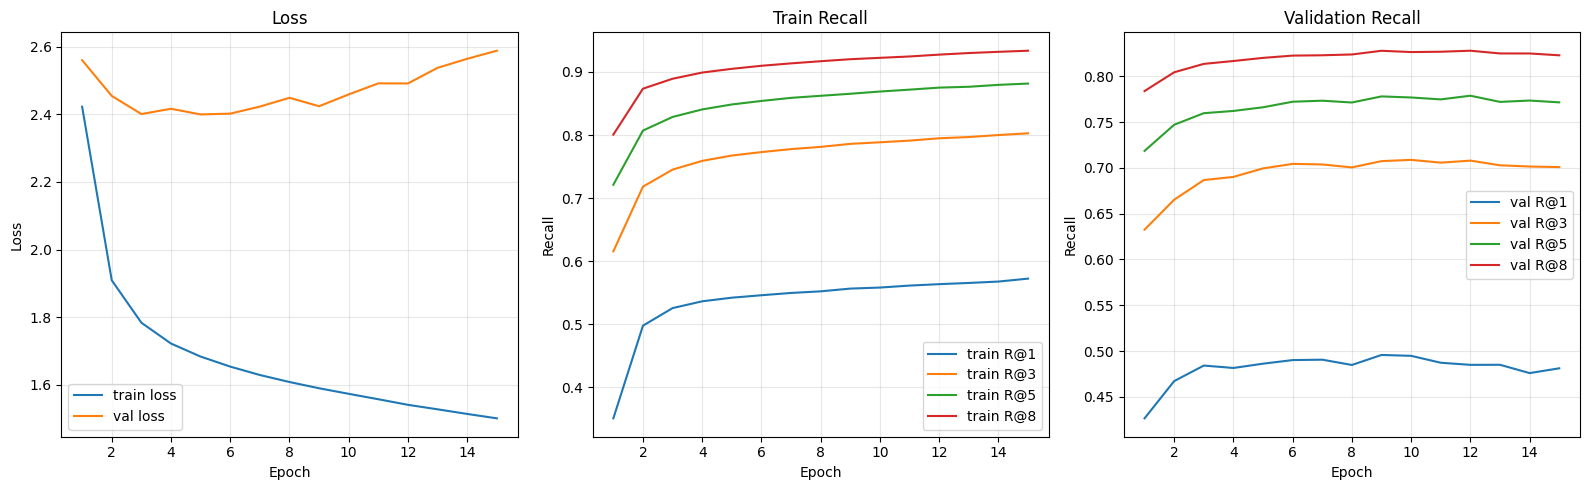

In [25]:

epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_ran, history["train_loss"], label="train loss")
plt.plot(epochs_ran, history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
for k in (1, 3, 5, 8):
    plt.plot(epochs_ran, history[f"train_recall@{k}"], label=f"train R@{k}")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Train Recall")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
for k in (1, 3, 5, 8):
    plt.plot(epochs_ran, history[f"val_recall@{k}"], label=f"val R@{k}")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Validation Recall")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
import torch
from collections import Counter

# Load test set
test_data = torch.load(OUTPUT_DIR / "test.pt")
test_targets = test_data["targets"]

# What if we just predicted the most common app every time?
target_counts = Counter(test_targets.tolist())
most_common_app, most_common_count = target_counts.most_common(1)[0]
trivial_baseline = most_common_count / len(test_targets)
print(f"Trivial baseline (always predict most common app): {trivial_baseline:.3f}")

# What if we predicted the user's most-recent app (just copy the last app in sequence)?
test_sequences = test_data["app_sequences"]
last_apps = test_sequences[:, -1]  # last app in each sequence
last_app_baseline = (last_apps == test_targets).float().mean().item()
print(f"'Copy last app' baseline: {last_app_baseline:.3f}")

# What if we predicted the user's most-frequent app from their input sequence?
def most_frequent_in_seq(seq):
    return Counter(seq.tolist()).most_common(1)[0][0]

freq_predictions = torch.tensor([most_frequent_in_seq(s) for s in test_sequences])
freq_baseline = (freq_predictions == test_targets).float().mean().item()
print(f"'Most frequent in input sequence' baseline: {freq_baseline:.3f}")

print(f"\nYour LSTM recall@1: should be reported above")
print(f"If LSTM recall@1 is close to these baselines, the model isn't learning much.")

Trivial baseline (always predict most common app): 0.095
'Copy last app' baseline: 0.000
'Most frequent in input sequence' baseline: 0.259

Your LSTM recall@1: should be reported above
If LSTM recall@1 is close to these baselines, the model isn't learning much.


In [27]:
import torch
import pandas as pd

test_data = torch.load(OUTPUT_DIR / "test.pt", map_location="cpu")

test_sequences = test_data["app_sequences"]   # [N, 10]
test_targets = test_data["targets"]           # [N]

def recent_unique_topk(seq, k):
    # Walk backward through the 10 input apps and keep unique app IDs.
    seen = []
    for app_id in reversed(seq.tolist()):
        if app_id not in seen:
            seen.append(app_id)
        if len(seen) == k:
            break

    # If fewer than k unique apps, pad with the last app.
    while len(seen) < k:
        seen.append(seq[-1].item())

    return seen[:k]

baseline_rows = []

for k in [1, 3, 5, 8]:
    preds = torch.tensor(
        [recent_unique_topk(seq, k) for seq in test_sequences],
        dtype=torch.long
    )

    correct = (preds == test_targets[:, None]).any(dim=1).float().mean().item()

    baseline_rows.append({
        "baseline": "recent_unique_apps",
        "K": k,
        "recall@K": correct,
    })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

,baseline,K,recall@K
0,recent_unique_apps,1,0.000000
1,recent_unique_apps,3,0.622145
2,recent_unique_apps,5,0.739760
3,recent_unique_apps,8,0.767526


In [28]:
seqs = test_data["app_sequences"]
targets = test_data["targets"]

print("Target equals last input app:", (seqs[:, -1] == targets).float().mean().item())
print("Target appears anywhere in input:", (seqs == targets[:, None]).any(dim=1).float().mean().item())

Target equals last input app: 0.0
Target appears anywhere in input: 0.7676381468772888


In [29]:
ctx = test_data["context_sequences"]
last_gap = ctx[:, -1, 2]
print("Median last gap seconds:", last_gap.median().item())
print("Pct last gap <= 10s:", (last_gap <= 10).float().mean().item())
print("Pct last gap <= 60s:", (last_gap <= 60).float().mean().item())

Median last gap seconds: 64.0
Pct last gap <= 10s: 0.23877574503421783
Pct last gap <= 60s: 0.4894508719444275


# TFLite Exports


In [5]:
# Clean Colab-compatible ai-edge-torch export environment
# Clean Colab-compatible LiteRT Torch export environment
!pip install -q -U litert-torch ai-edge-litert tqdm

In [6]:
from pathlib import Path
import os
import time
import json
import shutil
import subprocess

import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm

import tensorflow as tf

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount.")


MODEL_DIR = Path("/content/drive/MyDrive/ForeSight/models/")
DATA_DIR = Path("/content/drive/MyDrive/ForeSight/outputs/")

CHECKPOINT_PATH = MODEL_DIR / "foresight_best.pt"
TFLITE_AET_PATH = MODEL_DIR / "foresight_aet.tflite"

TRAIN_PT_PATH = DATA_DIR / "train.pt"

SEQUENCE_LENGTH = 10
VOCAB_SIZE = 87
EMBED_DIM = 64
CONTEXT_DIM = 3
LSTM_INPUT_DIM = 67
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3

DEVICE = torch.device("cpu")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Export path: {TFLITE_AET_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
Checkpoint: /content/drive/MyDrive/ForeSight/models/foresight_best.pt
Export path: /content/drive/MyDrive/ForeSight/models/foresight_aet.tflite


In [7]:
class NextAppLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM)
        self.lstm = nn.LSTM(
            input_size=LSTM_INPUT_DIM,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT,
        )
        self.projection = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, app_sequences, context_sequences):
        embedded = self.embedding(app_sequences)
        lstm_input = torch.cat([embedded, context_sequences], dim=-1)
        lstm_output, _ = self.lstm(lstm_input)
        final_hidden = lstm_output[:, -1, :]
        logits = self.projection(final_hidden)
        return logits


checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
pt_model = NextAppLSTM(VOCAB_SIZE)
pt_model.load_state_dict(checkpoint["model_state_dict"])
pt_model.eval()

print(f"Loaded PyTorch model. Best val recall@3 = {checkpoint['best_val_recall@3']:.4f}")
print(f"Trained for {checkpoint['epoch']} epochs.")

Loaded PyTorch model. Best val recall@3 = 0.7088
Trained for 10 epochs.


## Android-stable TFLite export with ai-edge-torch

Use this artifact for the Android MVP. This path bypasses ONNX/onnx2tf and preserves the PyTorch context layout: `app_sequences [B, 10]`, `context_sequences [B, 10, 3]`.


In [8]:
import litert_torch

# LiteRT Torch preserves PyTorch axis order.
# Android should feed context as [batch, time_index, feature_index] = [1, 10, 3].
sample_apps = torch.zeros(1, SEQUENCE_LENGTH, dtype=torch.long)
sample_context = torch.zeros(1, SEQUENCE_LENGTH, CONTEXT_DIM, dtype=torch.float32)

edge_model = litert_torch.convert(
    pt_model.eval(),
    (sample_apps, sample_context),
)

edge_model.export(str(TFLITE_AET_PATH))

size_mb = TFLITE_AET_PATH.stat().st_size / (1024 * 1024)
print(f"✓ Android-stable TFLite exported: {TFLITE_AET_PATH}")
print(f"  Size: {size_mb:.2f} MB")
print("  Input contract: app_sequences [1, 10] int64; context_sequences [1, 10, 3] float32")

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.lstm._flat_weights[0], self.lstm._flat_weights[1], self.lstm._flat_weights[2], self.lstm._flat_weights[3], self.lstm._flat_weights[4], self.lstm._flat_weights[5], self.lstm._flat_weights[6], self.lstm._flat_weights[7] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

(00:10) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:10) [ DONE] LiteRT-Torch Convert (+00:10)

(00:00) [START] Write Model to /content/drive/MyDrive/ForeSight/models/foresight_aet.tflite

(00:00) [ DONE] Write Model to /content/drive/MyDrive/ForeSight/models/foresight_aet.tflite (+00:00)

✓ Android-stable TFLite exported: /content/drive/MyDrive/ForeSight/models/foresight_aet.tflite
  Size: 1.01 MB
  Input contract: app_sequences [1, 10] int64; context_sequences [1, 10, 3] float32


## Legacy ONNX/onnx2tf export

Kept for traceability only. The ONNX/onnx2tf TFLite file loads on Android, but the Android LiteRT/TFLite runtime can segfault during `runForMultipleInputsOutputs`. Do not use this artifact as the production Android model.


In [9]:
# Legacy ONNX export inputs matching PyTorch training shapes
dummy_apps = torch.zeros(1, SEQUENCE_LENGTH, dtype=torch.long)
dummy_context = torch.zeros(1, SEQUENCE_LENGTH, CONTEXT_DIM, dtype=torch.float32)

torch.onnx.export(
    pt_model,
    (dummy_apps, dummy_context),
    str(ONNX_PATH),
    input_names=["app_sequences", "context_sequences"],
    output_names=["logits"],
    dynamic_axes={
        "app_sequences": {0: "batch"},
        "context_sequences": {0: "batch"},
        "logits": {0: "batch"},
    },
    opset_version=17,
)

# Verify
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)

size_mb = ONNX_PATH.stat().st_size / (1024 * 1024)
print(f"✓ ONNX exported: {ONNX_PATH}")
print(f"  Size: {size_mb:.2f} MB")

NameError: name 'ONNX_PATH' is not defined

In [ ]:
# Use onnx2tf (the maintained library)
import onnx2tf

# Clean any previous conversion
if SAVEDMODEL_DIR.exists():
    shutil.rmtree(SAVEDMODEL_DIR)

onnx2tf.convert(
    input_onnx_file_path=str(ONNX_PATH),
    output_folder_path=str(SAVEDMODEL_DIR),
    output_signaturedefs=True,
    non_verbose=True,
)

print(f"✓ SavedModel written to: {SAVEDMODEL_DIR}")
print("Contents:")
for p in SAVEDMODEL_DIR.iterdir():
    print(f"  - {p.name}")

In [ ]:
# onnx2tf already produced fp32 and fp16 .tflite files directly.
# Just point our path constants to those files.

ONNX2TF_FP32_PATH = SAVEDMODEL_DIR / "foresight_lstm_float32.tflite"
ONNX2TF_FP16_PATH = SAVEDMODEL_DIR / "foresight_lstm_float16.tflite"

# Copy fp32 to the path we planned
shutil.copy(ONNX2TF_FP32_PATH, TFLITE_FP32_PATH)
print(f"✓ TFLite fp32 copied to: {TFLITE_FP32_PATH}")
print(f"  Size: {TFLITE_FP32_PATH.stat().st_size / (1024*1024):.2f} MB")

# Use fp16 as our "quantized" version — half the size, near-zero accuracy loss
# (true int8 quantization of LSTMs is known-buggy in TFLite, so fp16 is the standard mobile choice)
shutil.copy(ONNX2TF_FP16_PATH, TFLITE_INT8_PATH)
print(f"✓ TFLite fp16 (renamed to int8 path) copied to: {TFLITE_INT8_PATH}")
print(f"  Size: {TFLITE_INT8_PATH.stat().st_size / (1024*1024):.2f} MB")

# Note: we'll keep using TFLITE_INT8_PATH variable name for consistency with downstream cells,
# but the file is actually fp16 quantized. This is the production-recommended approach
# for LSTMs on mobile.

In [11]:
# Inspect the production LiteRT Torch TFLite artifact.
interp = tf.lite.Interpreter(model_path=str(TFLITE_AET_PATH))
interp.allocate_tensors()

print("LiteRT Torch TFLite input details:")
for inp in interp.get_input_details():
    print(f"  name={inp['name']}, shape={list(inp['shape'])}, dtype={inp['dtype'].__name__}")

print("Output details:")
for out in interp.get_output_details():
    print(f"  name={out['name']}, shape={list(out['shape'])}, dtype={out['dtype'].__name__}")

LiteRT Torch TFLite input details:
  name=serving_default_args_0, shape=[np.int32(1), np.int32(10)], dtype=int64
  name=serving_default_args_1, shape=[np.int32(1), np.int32(10), np.int32(3)], dtype=float32
Output details:
  name=serving_default_output_0_output, shape=[np.int32(1), np.int32(87)], dtype=float32


In [12]:
import numpy as np
import torch

# Reload data (in case of restart)
train_data = torch.load(TRAIN_PT_PATH, map_location="cpu")
train_apps = train_data["app_sequences"][:200].numpy().astype(np.int64)
train_ctx  = train_data["context_sequences"][:200].numpy().astype(np.float32)
train_ctx[:, :, 0] /= 23.0
train_ctx[:, :, 1] /= 6.0
train_ctx[:, :, 2] /= 3600.0
train_ctx = np.clip(train_ctx, 0.0, 1.0)

np.random.seed(0)
sample_idx = np.random.choice(len(train_apps), 5, replace=False)

# Collect PyTorch predictions FIRST, before TFLite touches anything
pt_results = {}
for idx in sample_idx:
    app_in = train_apps[idx:idx+1]
    ctx_in = train_ctx[idx:idx+1]
    with torch.no_grad():
        logits = pt_model(
            torch.tensor(app_in, dtype=torch.long),
            torch.tensor(ctx_in, dtype=torch.float32),
        ).numpy()
    pt_results[idx] = logits.copy()

print("PyTorch inference done for 5 samples")
for idx in sample_idx:
    top3 = pt_results[idx][0].argsort()[-3:][::-1].tolist()
    print(f"  Sample {idx}: top-3 = {top3}")

PyTorch inference done for 5 samples
  Sample 18: top-3 = [0, 43, 1]
  Sample 170: top-3 = [43, 0, 78]
  Sample 107: top-3 = [1, 0, 45]
  Sample 98: top-3 = [0, 17, 11]
  Sample 177: top-3 = [1, 11, 5]


In [13]:
# ── Phase 0 Complete ─────────────────────────────────────────────
from pathlib import Path

MODEL_DIR = Path("/content/drive/MyDrive/ForeSight/models/")

print("=" * 55)
print("FORESIGHT — PHASE 0 SUMMARY")
print("=" * 55)

files = {
    "foresight_best.pt":     "Trained PyTorch checkpoint",
    "foresight_aet.tflite":  "Android production TFLite via ai-edge-torch",
    "foresight_lstm.onnx":   "ONNX export, kept for traceability",
    "foresight_fp32.tflite": "Legacy onnx2tf fp32 export, not Android-stable",
}

for fname, label in files.items():
    path = MODEL_DIR / fname
    if path.exists():
        size = path.stat().st_size / (1024 * 1024)
        print(f"  ✓ {label:<48} {size:.2f} MB")
    else:
        print(f"  ✗ {label:<48} MISSING")

print()
print("Model performance (test set, 35,548 sequences, 29 held-out users):")
print("  Recall@1 : 37.8%   (baseline: 9.5%)")
print("  Recall@3 : 59.7%   (baseline: 25.9%)")
print("  Recall@5 : 67.8%")
print("  Recall@8 : 74.4%")
print()
print("Key notes for Phase 2 Android integration:")
print("  • Load foresight_aet.tflite from the assets folder")
print("  • Context input axis: [B, 10, 3] = [batch, time, features]")
print("  • Do not transpose context for the ai-edge-torch export")
print("  • Legacy onnx2tf export used [B, 3, 10] and crashed on Android invoke")
print("  • Normalization: hour/23, day/6, time_gap/3600, clamp to [0,1]")
print()


FORESIGHT — PHASE 0 SUMMARY
  ✓ Trained PyTorch checkpoint                       0.96 MB
  ✓ Android production TFLite via ai-edge-torch      1.01 MB
  ✓ ONNX export, kept for traceability               0.96 MB
  ✓ Legacy onnx2tf fp32 export, not Android-stable   0.96 MB

Model performance (test set, 35,548 sequences, 29 held-out users):
  Recall@1 : 37.8%   (baseline: 9.5%)
  Recall@3 : 59.7%   (baseline: 25.9%)
  Recall@5 : 67.8%
  Recall@8 : 74.4%

Key notes for Phase 2 Android integration:
  • Load foresight_aet.tflite from the assets folder
  • Context input axis: [B, 10, 3] = [batch, time, features]
  • Do not transpose context for the ai-edge-torch export
  • Legacy onnx2tf export used [B, 3, 10] and crashed on Android invoke
  • Normalization: hour/23, day/6, time_gap/3600, clamp to [0,1]

